In [4]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import(LabelEncoder, StandardScaler, MinMaxScaler)
from sklearn.model_selection import (train_test_split, GridSearchCV)
from sklearn.cluster import (KMeans, AgglomerativeClustering)
from sklearn.metrics import (silhouette_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import (linkage, dendrogram)
import joblib

import warnings 
warnings.filterwarnings('ignore')

In [5]:
#Loading the dataset
df = pd.read_csv('SkyCity Auckland Restaurants & Bars.csv')

#Display the first 5 rows of the dataset
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [6]:
#Dataset Shape
print("Dataset Shape:", df.shape)

#Number of Rows and Columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1696, 30)
Number of Rows: 1696
Number of Columns: 30


In [7]:
#Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   str    
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   str    
 3   Segment                1696 non-null   str    
 4   Subregion              1696 non-null   str    
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  SelfDeliveryRev

In [8]:
# Checking Data Types
df.dtypes

CuisineType                  str
RestaurantID               int64
RestaurantName               str
Segment                      str
Subregion                    str
GrowthFactor             float64
AOV                      float64
MonthlyOrders              int64
InStoreOrders              int64
InStoreRevenue           float64
UberEatsOrders             int64
DoorDashOrders             int64
SelfDeliveryOrders         int64
UberEatsRevenue          float64
DoorDashRevenue          float64
SelfDeliveryRevenue      float64
COGSRate                 float64
OPEXRate                 float64
CommissionRate           float64
DeliveryRadiusKM           int64
DeliveryCostPerOrder     float64
SD_DeliveryTotalCost     float64
InStoreNetProfit         float64
UberEatsNetProfit        float64
DoorDashNetProfit        float64
SelfDeliveryNetProfit    float64
InStoreShare             float64
UE_share                 float64
DD_share                 float64
SD_share                 float64
dtype: obj

In [9]:
# Statistical Summary
df.describe()

,RestaurantID,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,...,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,25848.500000,1.028255,38.516887,1190.527123,218.980542,8422.392730,471.906250,257.155071,242.485259,18170.030360,...,3.119363,755.783886,2257.321557,152.410425,89.105100,2139.315118,0.225654,0.486763,0.265242,0.247995
std,489.737345,0.022700,4.459408,422.334848,149.758619,5851.233352,171.781981,92.605301,129.950736,6959.241673,...,1.344848,541.323056,1618.692119,2340.125579,1271.832584,1875.802610,0.126977,0.067685,0.034294,0.094582
min,25001.000000,0.990000,29.790000,441.000000,13.000000,412.360000,142.000000,81.000000,60.000000,5050.950000,...,0.890000,53.400000,155.000000,-7787.110000,-4349.940000,-983.280000,0.030000,0.350000,0.200000,0.150000
25%,25424.750000,1.030000,34.787500,827.000000,101.000000,3904.342500,331.000000,179.750000,146.000000,12524.745000,...,1.770000,358.662500,1122.580000,-1291.512500,-718.617500,807.867500,0.110000,0.450000,0.250000,0.150000
50%,25848.500000,1.040000,38.340000,1182.000000,178.000000,6791.430000,456.000000,249.000000,212.000000,17548.980000,...,3.250000,601.800000,1785.720000,676.685000,369.665000,1742.945000,0.210000,0.500000,0.250000,0.200000
75%,26272.250000,1.050000,42.495000,1525.000000,307.000000,11550.755000,602.000000,326.250000,306.250000,23016.000000,...,4.130000,1005.030000,2848.090000,1581.570000,862.602500,2995.282500,0.320000,0.550000,0.300000,0.300000
max,26696.000000,1.050000,47.230000,2337.000000,819.000000,35356.230000,937.000000,466.000000,702.000000,43038.960000,...,5.310000,3653.280000,10474.680000,8275.570000,4514.880000,13222.100000,0.550000,0.600000,0.300000,0.450000


In [10]:
#Checking Duplicates Records
print("Number of Duplicate Records:", df.duplicated().sum())

Number of Duplicate Records: 0


In [11]:
#Removing Duplicate Records
df = df.drop_duplicates()

#Checking the shape of the dataset after removing duplicates
print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (1696, 30)


In [12]:
# Renaming Columns (Optional for Better Readability)
df.columns = df.columns.str.strip()

In [13]:
# Checking Null Values Percentage
null_percentage = (df.isnull().sum() / len(df)) * 100
print(null_percentage)

CuisineType              0.0
RestaurantID             0.0
RestaurantName           0.0
Segment                  0.0
Subregion                0.0
GrowthFactor             0.0
AOV                      0.0
MonthlyOrders            0.0
InStoreOrders            0.0
InStoreRevenue           0.0
UberEatsOrders           0.0
DoorDashOrders           0.0
SelfDeliveryOrders       0.0
UberEatsRevenue          0.0
DoorDashRevenue          0.0
SelfDeliveryRevenue      0.0
COGSRate                 0.0
OPEXRate                 0.0
CommissionRate           0.0
DeliveryRadiusKM         0.0
DeliveryCostPerOrder     0.0
SD_DeliveryTotalCost     0.0
InStoreNetProfit         0.0
UberEatsNetProfit        0.0
DoorDashNetProfit        0.0
SelfDeliveryNetProfit    0.0
InStoreShare             0.0
UE_share                 0.0
DD_share                 0.0
SD_share                 0.0
dtype: float64


In [14]:
# Separating Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns :\n", numerical_cols)
print("\nCategorical Columns :\n", categorical_cols)

Numerical Columns :
 Index(['RestaurantID', 'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share'],
      dtype='str')

Categorical Columns :
 Index(['CuisineType', 'RestaurantName', 'Segment', 'Subregion'], dtype='str')


In [15]:
# Checking Unique Values in Categorical Columns
for col in categorical_cols:
    print(f"\nUnique Values in {col} :")
    print(df[col].unique())


Unique Values in CuisineType :
<ArrowStringArray>
[             'Burgers',       'Chicken Dishes',              'Chinese',
               'Indian',             'Japanese', 'Kebabs/Mediterranean',
                'Pizza',                 'Thai']
Length: 8, dtype: str

Unique Values in RestaurantName :
<ArrowStringArray>
[   'Urban Burgers House',    'Urban Burgers Diner',    'King Burgers Eatery',
 'Classic Burgers Tavern',   'Lucky Burgers Bistro',   'King Burgers Kitchen',
   'Urban Burgers Eatery',   'Urban Burgers Tavern',     'Lucky Burgers Cafe',
   'Lucky Burgers Eatery',
 ...
   'Classic Pizza Tavern',       'Top Pizza Corner',       'King Pizza House',
      'Lucky Pizza Diner',    'Lucky Pizza Kitchen',        'King Pizza Cafe',
     'King Pizza Kitchen',  'Classic Pizza Kitchen',      'Top Pizza Kitchen',
   'Classic Pizza Corner']
Length: 256, dtype: str

Unique Values in Segment :
<ArrowStringArray>
['Cafe', 'QSR', 'Ghost Kitchen', 'Full-service']
Length: 4, dtype: str

Un

In [16]:
# Encoding Categorical Features
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display Dataset After Encoding
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,0,25731,236,0,1,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,0,25123,233,3,2,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,0,25177,76,0,3,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,0,25540,17,3,1,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,0,25258,107,0,2,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [17]:
# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Converting Back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

# Display Scaled Dataset
scaled_df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,-1.299978,-0.239995,1.554745,-1.198331,-0.498813,0.076907,1.223194,-1.237599,-0.146816,0.040977,...,0.097167,-0.549804,0.880488,0.512961,0.521980,0.020197,1.531011,-0.543305,-0.444569,0.549997
1,-1.299978,-1.481843,1.513421,1.265147,0.387037,0.958215,0.433619,0.467712,0.267305,0.351168,...,1.190550,1.560150,0.833263,0.498496,0.505628,0.522632,0.034233,-0.543305,-0.444569,0.549997
2,-1.299978,-1.371548,-0.649171,-1.198331,1.272888,0.517561,0.339408,1.246945,2.037341,2.146048,...,0.097167,0.753407,3.431948,0.599927,0.608998,1.084482,1.688566,-0.543305,-0.444569,0.549997
3,-1.299978,-0.630115,-1.461865,1.265147,-0.498813,0.076907,-0.501759,-0.254677,-0.019908,-0.100164,...,-1.658195,-0.968994,0.178406,-0.096032,-0.101698,0.370055,0.191789,-0.543305,-0.444569,0.549997
4,-1.299978,-1.206104,-0.222162,-1.198331,0.387037,0.958215,-0.936922,0.093491,0.280664,0.092375,...,-0.341673,0.033772,0.516476,0.031529,0.028648,0.285426,0.349344,-0.543305,-0.444569,0.549997


In [18]:
# Correlation Matrix
correlation_matrix = df.corr()

# Display Correlation Matrix
correlation_matrix

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
CuisineType,1.000000,0.028255,0.019133,0.020555,-0.015988,-0.011068,-0.030490,-0.083307,-0.220479,-0.225169,...,0.001074,0.047345,-0.230320,-0.001311,-0.001356,0.035843,-0.272825,-0.189966,0.109702,0.096168
RestaurantID,0.028255,1.000000,-0.037704,-0.016463,-0.012846,-0.000948,-0.008194,0.019201,0.017721,0.016692,...,0.004221,0.009486,-0.005974,-0.022516,-0.022380,-0.017444,0.015442,-0.007389,0.018318,-0.001354
RestaurantName,0.019133,-0.037704,1.000000,0.018886,0.008714,0.003368,-0.030567,-0.015890,-0.010023,-0.009949,...,0.048698,0.047000,0.040599,0.038335,0.040459,0.042623,-0.005020,-0.023425,-0.051719,0.035516
Segment,0.020555,-0.016463,0.018886,1.000000,0.031891,0.037114,0.015632,-0.102269,-0.271722,-0.261179,...,-0.008922,-0.002939,-0.149763,0.210536,0.210035,0.144482,-0.336966,0.002945,0.024385,-0.010949
Subregion,-0.015988,-0.012846,0.008714,0.031891,1.000000,0.831498,0.178625,0.028856,0.013755,0.045306,...,0.001188,0.025939,0.064407,0.024441,0.020054,0.061490,-0.010781,-0.006242,-0.015324,0.010023
GrowthFactor,-0.011068,-0.000948,0.003368,0.037114,0.831498,1.000000,0.213869,0.041534,0.017199,0.055552,...,-0.011000,0.026945,0.065249,0.023260,0.021239,0.079109,-0.012969,0.001658,-0.031742,0.010323
AOV,-0.030490,-0.008194,-0.030567,0.015632,0.178625,0.213869,1.000000,-0.009851,-0.018063,0.148073,...,-0.036580,-0.008339,0.183052,0.074984,0.079186,0.230702,-0.009701,-0.004815,-0.019080,0.010364
MonthlyOrders,-0.083307,0.019201,-0.015890,-0.102269,0.028856,0.041534,-0.009851,1.000000,0.735693,0.720294,...,-0.014768,0.529915,0.588038,-0.157143,-0.159446,0.327260,0.298658,-0.131005,-0.200637,0.166499
InStoreOrders,-0.220479,0.017721,-0.010023,-0.271722,0.013755,0.017199,-0.018063,0.735693,1.000000,0.979680,...,-0.004753,0.437631,0.624159,-0.491270,-0.492347,0.000555,0.829888,-0.270418,-0.461430,0.360826
InStoreRevenue,-0.225169,0.016692,-0.009949,-0.261179,0.045306,0.055552,0.148073,0.720294,0.979680,1.000000,...,-0.009609,0.429399,0.656504,-0.473543,-0.474003,0.042482,0.815383,-0.265637,-0.457903,0.356126


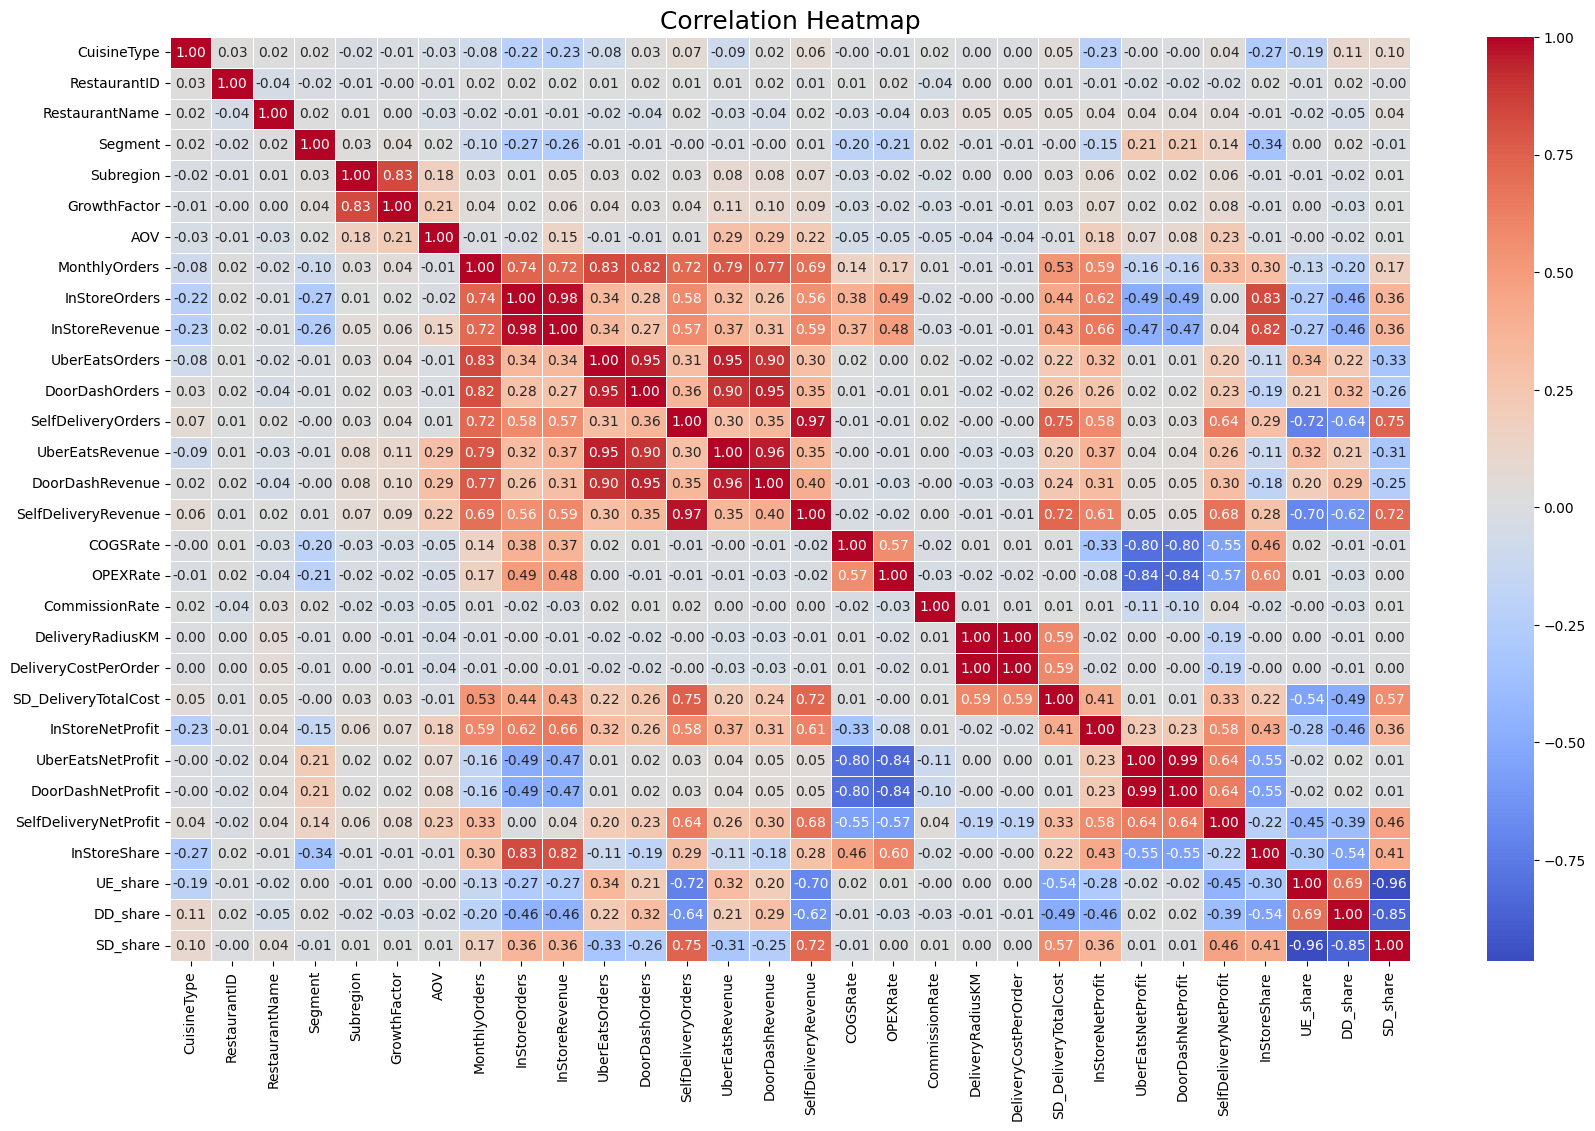

In [19]:
# Correlation Heatmap

plt.figure(figsize=(20, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=18)
plt.show()

In [22]:
# Correlation with Net Profit Features
profit_correlation = correlation_matrix[[
    'InStoreNetProfit',
    'UberEatsNetProfit',
    'DoorDashNetProfit',
    'SelfDeliveryNetProfit'
]]
profit_correlation

,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit
CuisineType,-0.230320,-0.001311,-0.001356,0.035843
RestaurantID,-0.005974,-0.022516,-0.022380,-0.017444
RestaurantName,0.040599,0.038335,0.040459,0.042623
Segment,-0.149763,0.210536,0.210035,0.144482
Subregion,0.064407,0.024441,0.020054,0.061490
GrowthFactor,0.065249,0.023260,0.021239,0.079109
AOV,0.183052,0.074984,0.079186,0.230702
MonthlyOrders,0.588038,-0.157143,-0.159446,0.327260
InStoreOrders,0.624159,-0.491270,-0.492347,0.000555
InStoreRevenue,0.656504,-0.473543,-0.474003,0.042482


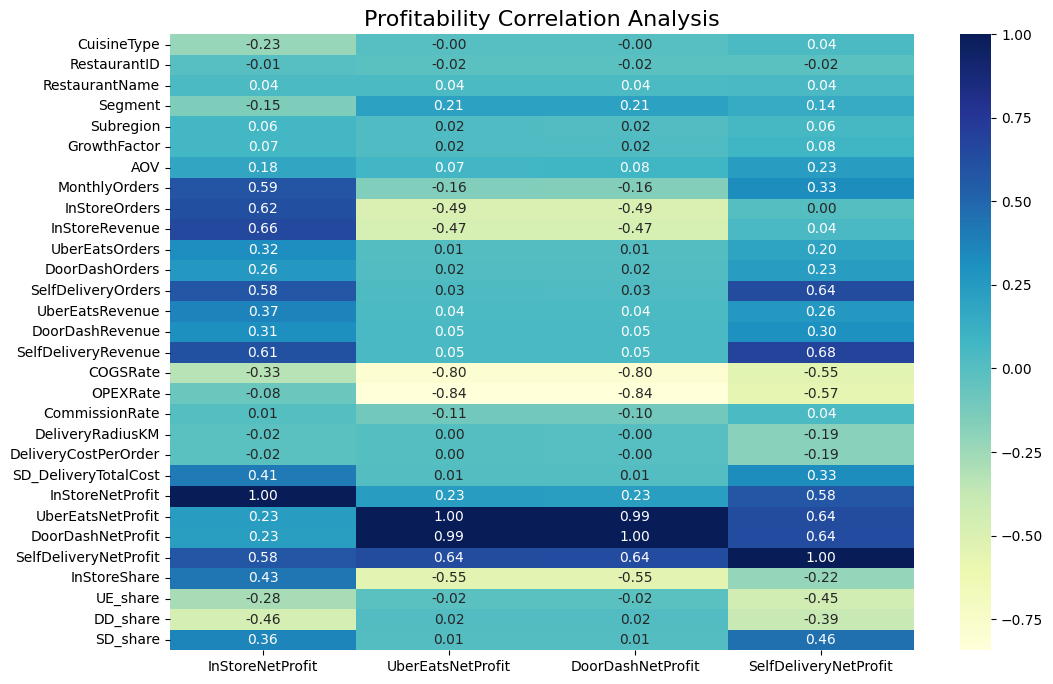

In [23]:
# Heatmap for Profit Correlation Features
plt.figure(figsize=(12, 8))
sns.heatmap(
    profit_correlation,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)
plt.title("Profitability Correlation Analysis", fontsize=16)
plt.show()

In [24]:
# Top Positive Correlations
top_positive_corr = correlation_matrix.unstack().sort_values(ascending=False)
top_positive_corr.head(20)

InStoreRevenue         InStoreRevenue           1.0
SelfDeliveryNetProfit  SelfDeliveryNetProfit    1.0
UberEatsOrders         UberEatsOrders           1.0
InStoreShare           InStoreShare             1.0
AOV                    AOV                      1.0
SelfDeliveryOrders     SelfDeliveryOrders       1.0
DoorDashNetProfit      DoorDashNetProfit        1.0
RestaurantName         RestaurantName           1.0
DoorDashOrders         DoorDashOrders           1.0
MonthlyOrders          MonthlyOrders            1.0
OPEXRate               OPEXRate                 1.0
CommissionRate         CommissionRate           1.0
DeliveryRadiusKM       DeliveryRadiusKM         1.0
DeliveryCostPerOrder   DeliveryCostPerOrder     1.0
Segment                Segment                  1.0
SD_DeliveryTotalCost   SD_DeliveryTotalCost     1.0
UE_share               UE_share                 1.0
InStoreOrders          InStoreOrders            1.0
InStoreNetProfit       InStoreNetProfit         1.0
UberEatsNetP

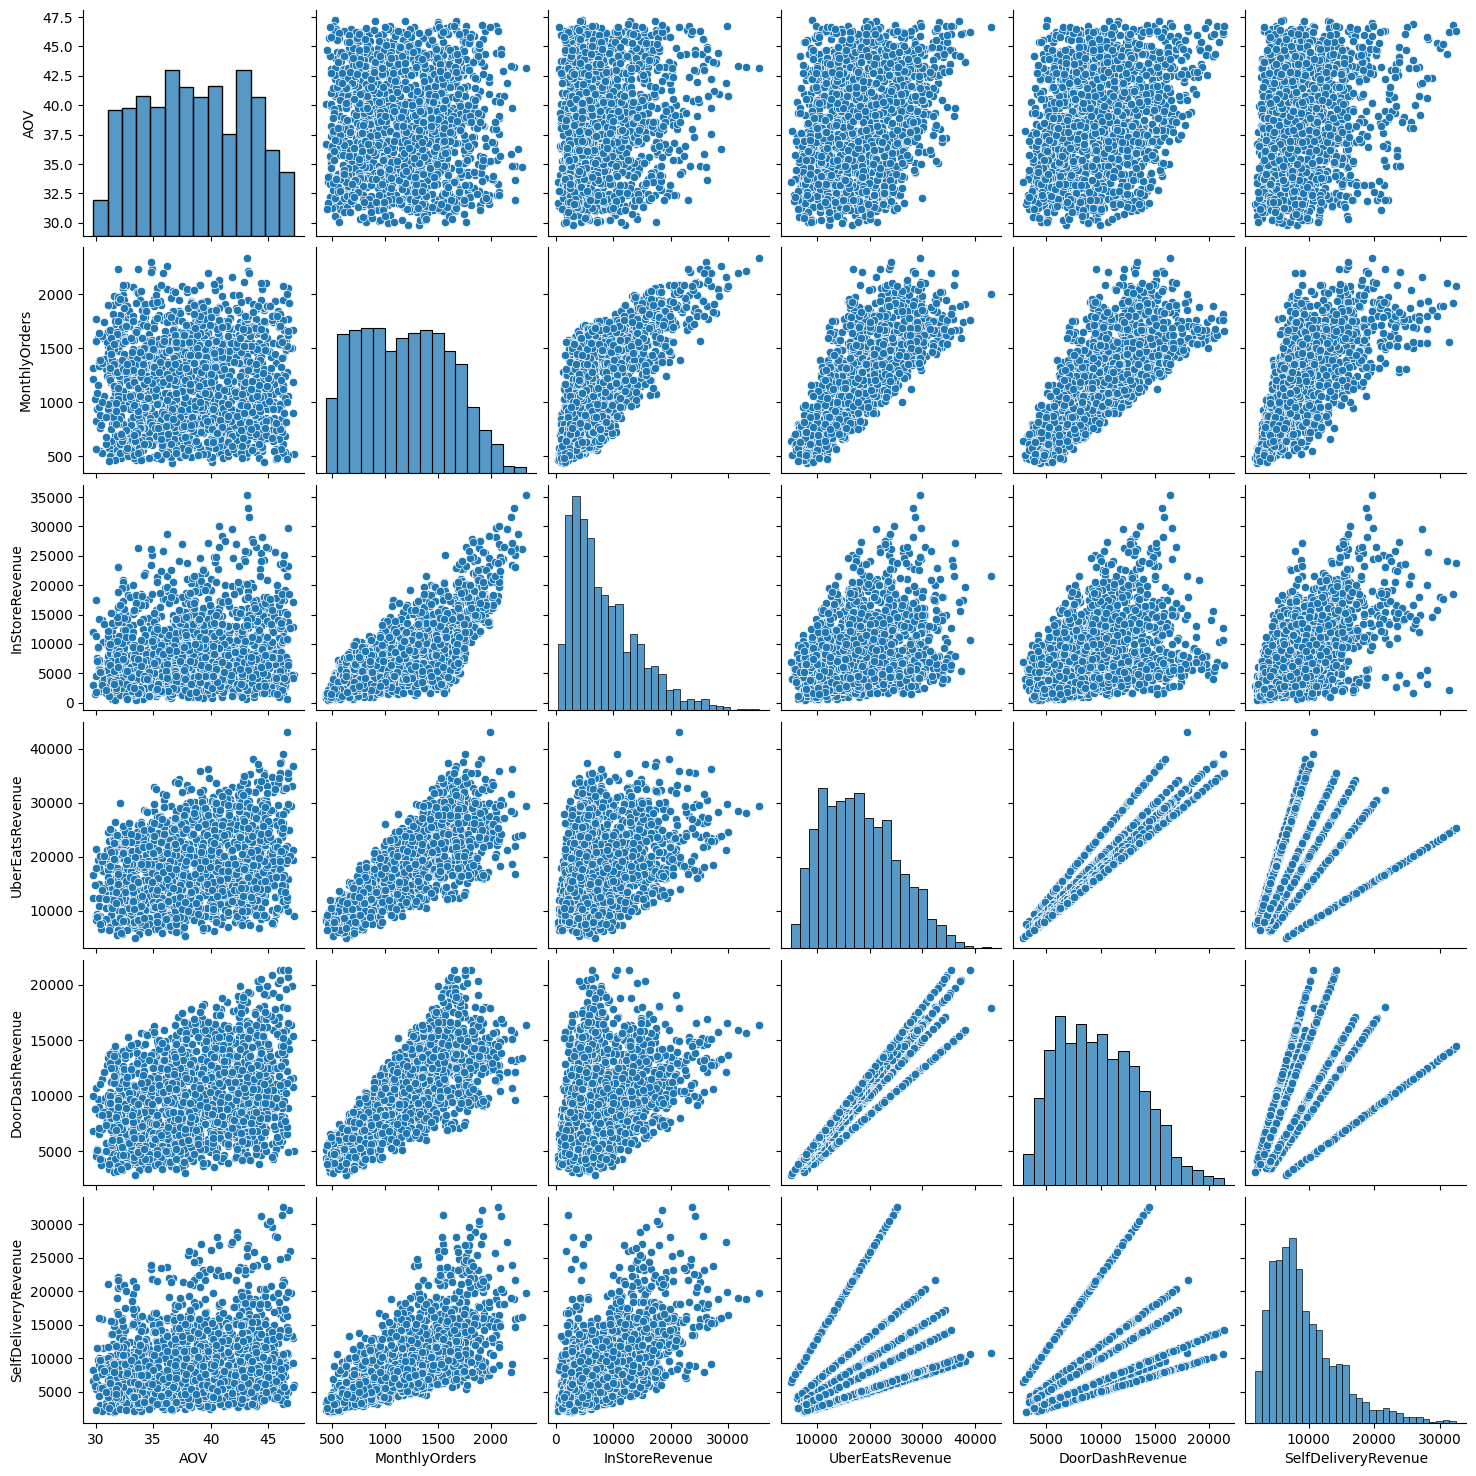

In [25]:
# Pairplot for Important Financial Features
important_features = [
    'AOV',
    'MonthlyOrders',
    'InStoreRevenue',
    'UberEatsRevenue',
    'DoorDashRevenue',
    'SelfDeliveryRevenue'
]
sns.pairplot(df[important_features])
plt.show()

In [26]:
# Selecting Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Display Numerical Columns
numerical_cols

Index(['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion',
       'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share'],
      dtype='str')

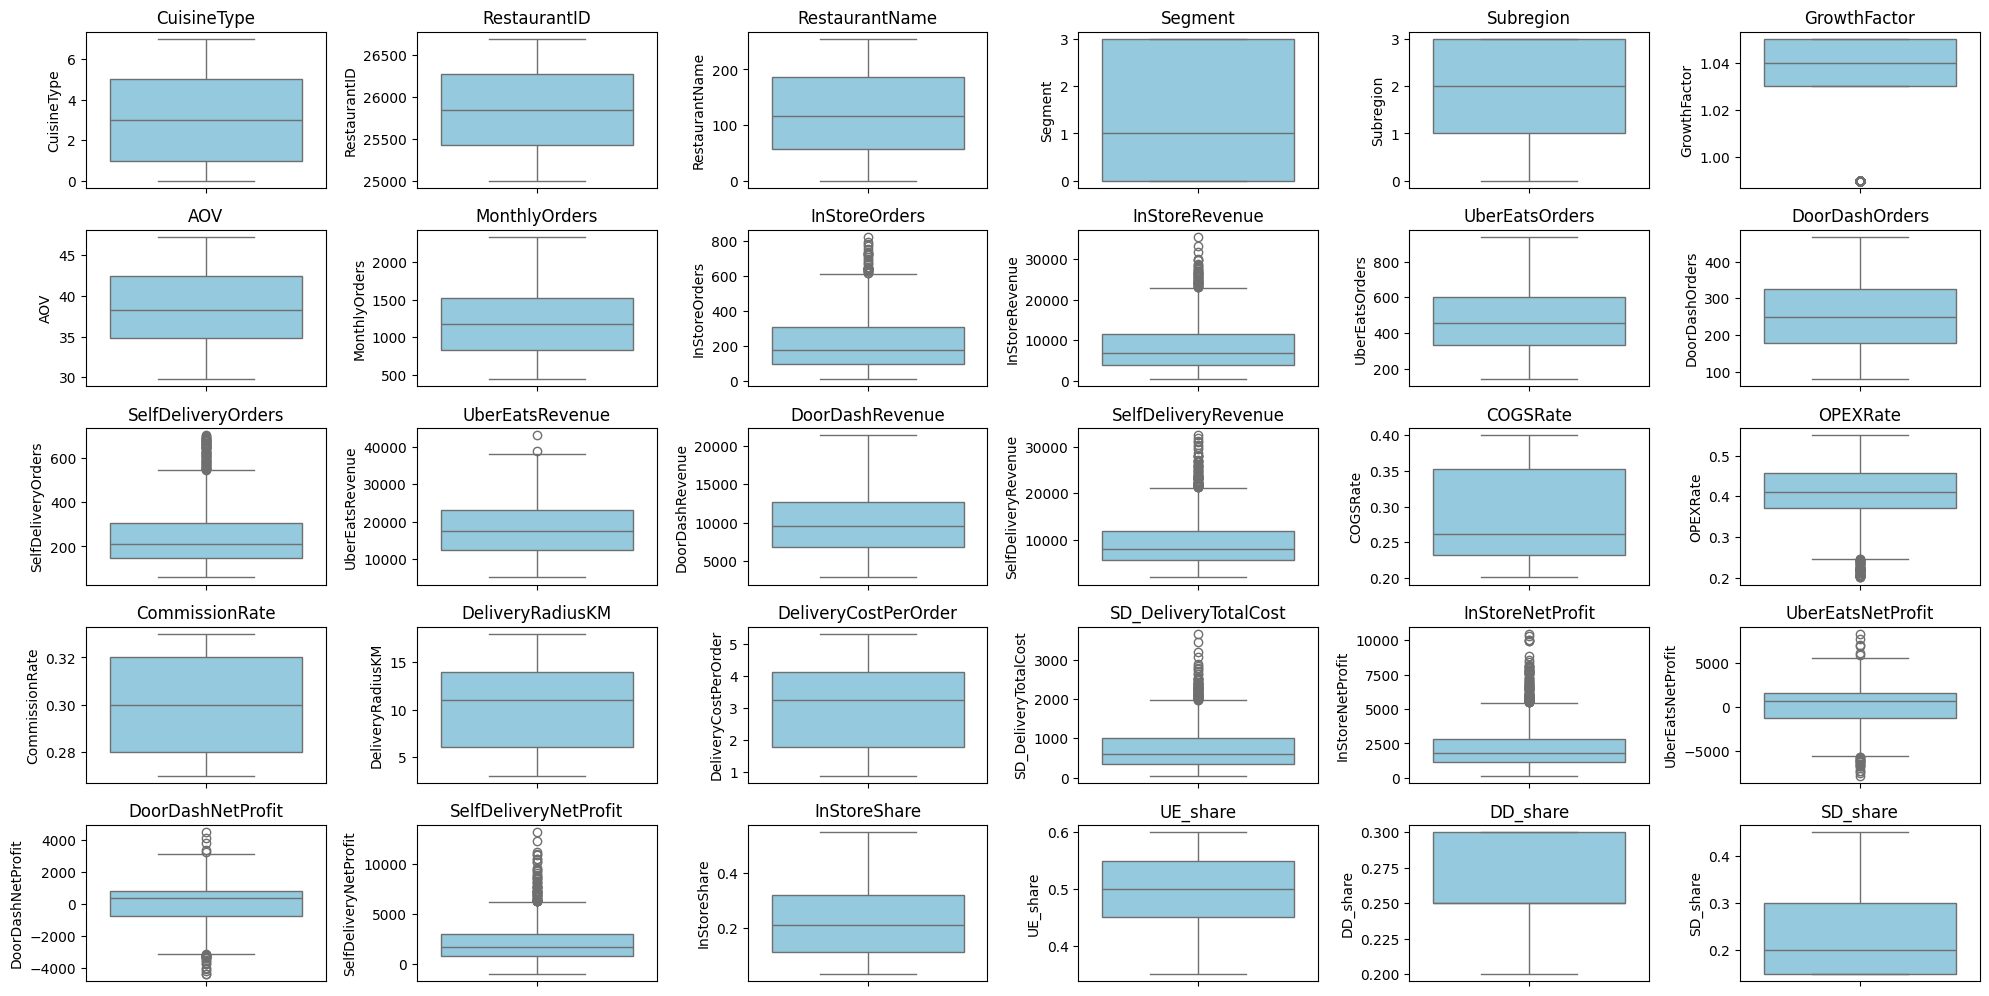

In [27]:
# Boxplot Visualization for Outlier Detection
plt.figure(figsize=(20, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(6, 6, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()
plt.show()

In [28]:
# Statistical Summary for Numerical Features
df[numerical_cols].describe()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,...,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,2.971698,25848.500000,123.128538,1.459316,1.563090,1.028255,38.516887,1190.527123,218.980542,8422.392730,...,3.119363,755.783886,2257.321557,152.410425,89.105100,2139.315118,0.225654,0.486763,0.265242,0.247995
std,2.286634,489.737345,72.619475,1.218150,1.129191,0.022700,4.459408,422.334848,149.758619,5851.233352,...,1.344848,541.323056,1618.692119,2340.125579,1271.832584,1875.802610,0.126977,0.067685,0.034294,0.094582
min,0.000000,25001.000000,0.000000,0.000000,0.000000,0.990000,29.790000,441.000000,13.000000,412.360000,...,0.890000,53.400000,155.000000,-7787.110000,-4349.940000,-983.280000,0.030000,0.350000,0.200000,0.150000
25%,1.000000,25424.750000,58.000000,0.000000,1.000000,1.030000,34.787500,827.000000,101.000000,3904.342500,...,1.770000,358.662500,1122.580000,-1291.512500,-718.617500,807.867500,0.110000,0.450000,0.250000,0.150000
50%,3.000000,25848.500000,116.500000,1.000000,2.000000,1.040000,38.340000,1182.000000,178.000000,6791.430000,...,3.250000,601.800000,1785.720000,676.685000,369.665000,1742.945000,0.210000,0.500000,0.250000,0.200000
75%,5.000000,26272.250000,187.000000,3.000000,3.000000,1.050000,42.495000,1525.000000,307.000000,11550.755000,...,4.130000,1005.030000,2848.090000,1581.570000,862.602500,2995.282500,0.320000,0.550000,0.300000,0.300000
max,7.000000,26696.000000,255.000000,3.000000,3.000000,1.050000,47.230000,2337.000000,819.000000,35356.230000,...,5.310000,3653.280000,10474.680000,8275.570000,4514.880000,13222.100000,0.550000,0.600000,0.300000,0.450000


In [29]:
# Detecting Outliers Using IQR Method
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Lower and Upper Limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifying Outliers
outliers = ((df[numerical_cols] < lower_bound) |
            (df[numerical_cols] > upper_bound))
# Counting Outliers
outliers.sum()

CuisineType                0
RestaurantID               0
RestaurantName             0
Segment                    0
Subregion                  0
GrowthFactor             410
AOV                        0
MonthlyOrders              0
InStoreOrders             32
InStoreRevenue            45
UberEatsOrders             0
DoorDashOrders             0
SelfDeliveryOrders        62
UberEatsRevenue            2
DoorDashRevenue            0
SelfDeliveryRevenue       67
COGSRate                   0
OPEXRate                  58
CommissionRate             0
DeliveryRadiusKM           0
DeliveryCostPerOrder       0
SD_DeliveryTotalCost      72
InStoreNetProfit          96
UberEatsNetProfit         26
DoorDashNetProfit         26
SelfDeliveryNetProfit     59
InStoreShare               0
UE_share                   0
DD_share                   0
SD_share                   0
dtype: int64

In [30]:
# Total Outlier Count
total_outliers = outliers.sum().sum()
print("Total Number of Outliers :", total_outliers)

Total Number of Outliers : 955


In [31]:
# Percentage of Outliers
outlier_percentage = (total_outliers / (df.shape[0] * len(numerical_cols))) * 100
print("Outlier Percentage :", round(outlier_percentage, 2), "%")

Outlier Percentage : 1.88 %


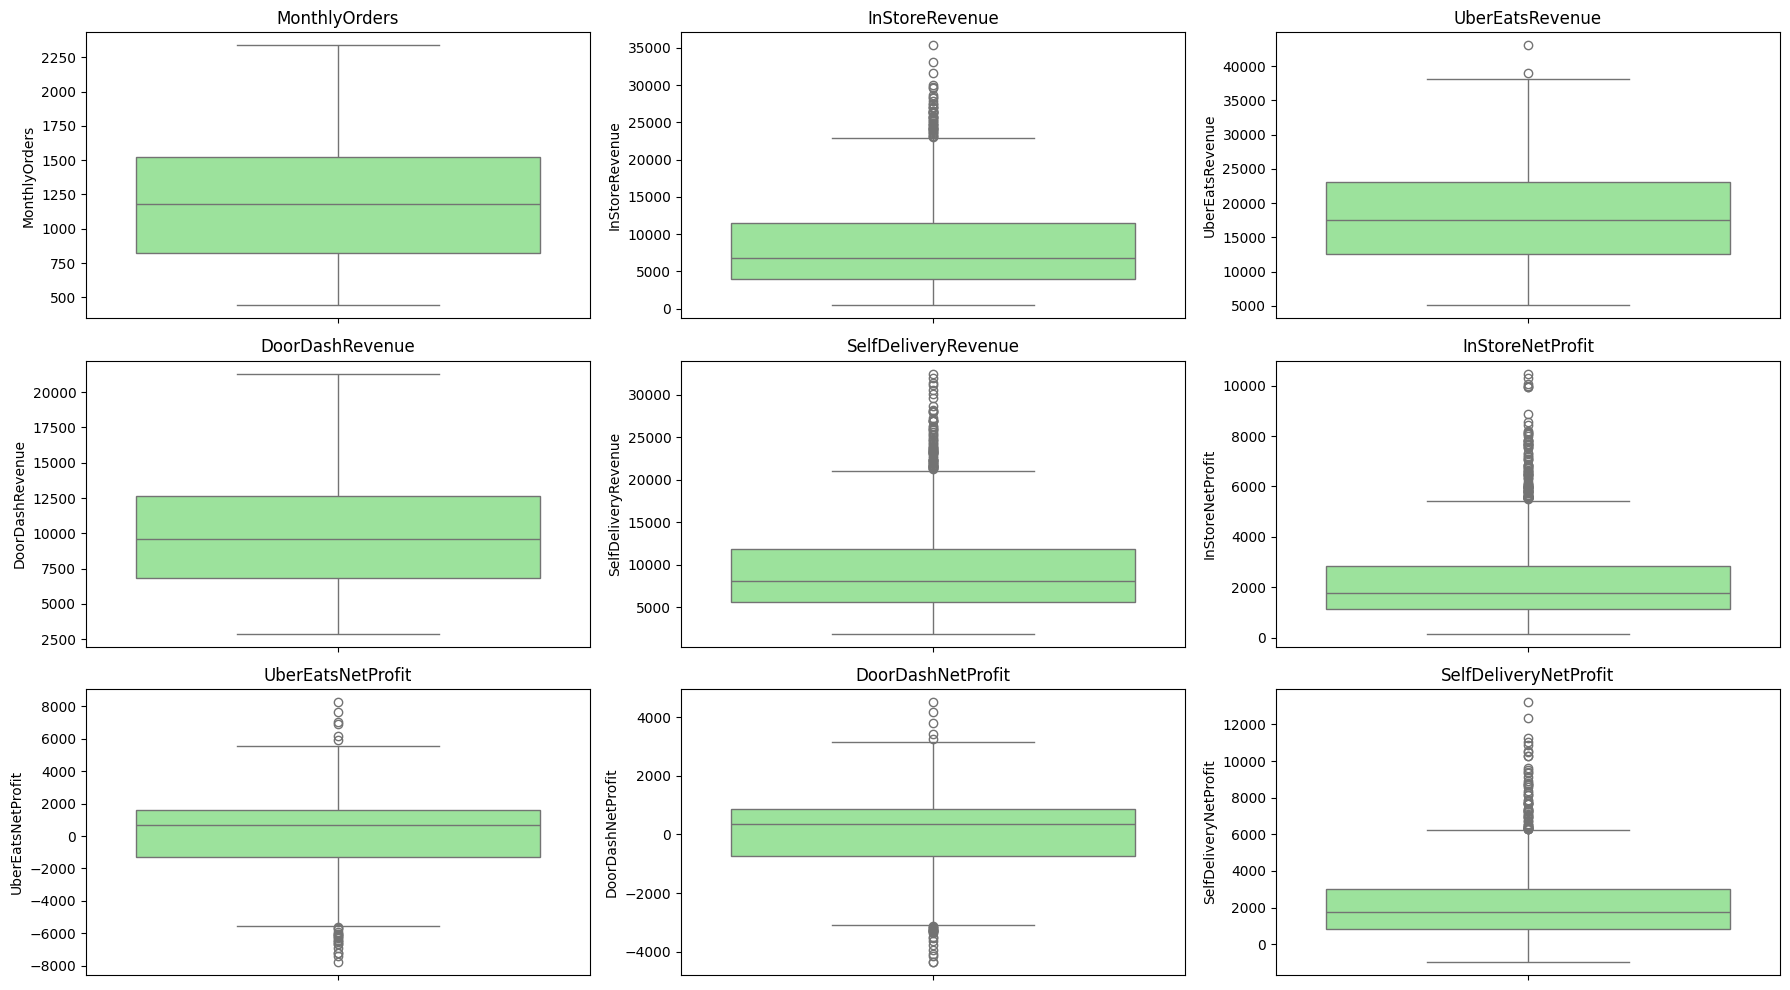

In [32]:
# Visualizing Important Financial Features
important_features = [
    'MonthlyOrders',
    'InStoreRevenue',
    'UberEatsRevenue',
    'DoorDashRevenue',
    'SelfDeliveryRevenue',
    'InStoreNetProfit',
    'UberEatsNetProfit',
    'DoorDashNetProfit',
    'SelfDeliveryNetProfit'
]
plt.figure(figsize=(18, 10))
for i, col in enumerate(important_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
    plt.tight_layout()
plt.show()

In [33]:
# Shape of the Dataset
df.shape

(1696, 30)

In [34]:
# Handling Outliers using IQR Capping Method

# Selecting Numerical Columns
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Applying IQR-Based Outlier Capping
for col in numerical_cols:

    # Calculating Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculating IQR
    IQR = Q3 - Q1

    # Defining Lower and Upper Bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Applying Lower Bound Capping
    df[col] = np.where(
        df[col] < lower_bound,
        lower_bound,
        df[col]
    )

    # Applying Upper Bound Capping
    df[col] = np.where(
        df[col] > upper_bound,
        upper_bound,
        df[col]
    )

# Displaying Dataset After Outlier Treatment
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,0.0,25731.0,236.0,0.0,1.0,1.03,43.97,668.0,197.0,8662.09,...,3.25,458.25,3682.140,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,0.0,25123.0,233.0,3.0,2.0,1.05,40.45,1388.0,259.0,10476.55,...,4.72,1600.08,3605.720,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,0.0,25177.0,76.0,0.0,3.0,1.04,40.03,1717.0,524.0,20975.72,...,3.25,1163.50,5436.355,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,0.0,25540.0,17.0,3.0,1.0,1.03,36.28,1083.0,216.0,7836.48,...,0.89,231.40,2546.020,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,0.0,25258.0,107.0,0.0,2.0,1.05,34.34,1230.0,261.0,8962.74,...,2.66,774.06,3093.090,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [36]:
#Rechecking outliers after treatment 
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_after = (
    (df[numerical_cols] < lower_bound) |
    (df[numerical_cols] > upper_bound)
)

# Counting Remaining Outliers
print(outliers_after.sum())

CuisineType              0
RestaurantID             0
RestaurantName           0
Segment                  0
Subregion                0
GrowthFactor             0
AOV                      0
MonthlyOrders            0
InStoreOrders            0
InStoreRevenue           0
UberEatsOrders           0
DoorDashOrders           0
SelfDeliveryOrders       0
UberEatsRevenue          0
DoorDashRevenue          0
SelfDeliveryRevenue      0
COGSRate                 0
OPEXRate                 0
CommissionRate           0
DeliveryRadiusKM         0
DeliveryCostPerOrder     0
SD_DeliveryTotalCost     0
InStoreNetProfit         0
UberEatsNetProfit        0
DoorDashNetProfit        0
SelfDeliveryNetProfit    0
InStoreShare             0
UE_share                 0
DD_share                 0
SD_share                 0
dtype: int64


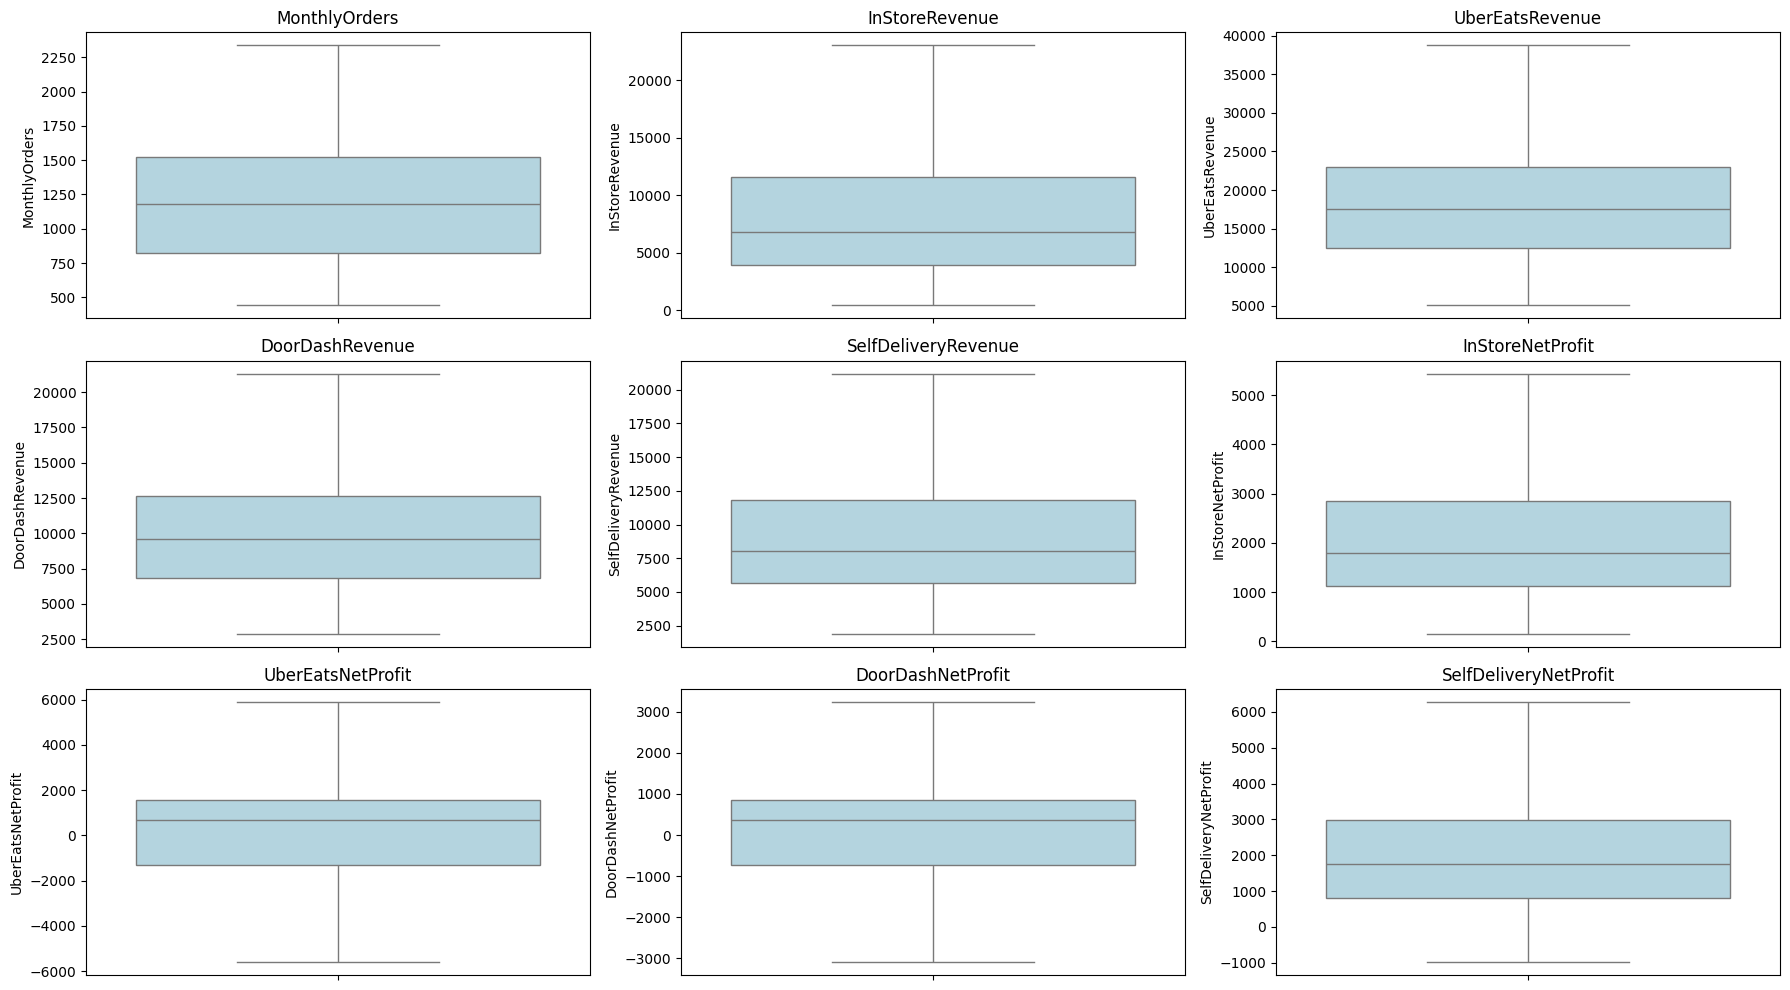

In [37]:
# Visualizing Boxplots after Outlier Treatment
important_features = [
    'MonthlyOrders',
    'InStoreRevenue',
    'UberEatsRevenue',
    'DoorDashRevenue',
    'SelfDeliveryRevenue',
    'InStoreNetProfit',
    'UberEatsNetProfit',
    'DoorDashNetProfit',
    'SelfDeliveryNetProfit'
]
plt.figure(figsize=(18, 10))
for i, col in enumerate(important_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(
        y=df[col],
        color='lightblue'
    )
    plt.title(col)
    plt.tight_layout()
plt.show()

In [38]:
# Creating Total Revenue Feature
df['TotalRevenue'] = (
    df['InStoreRevenue'] +
    df['UberEatsRevenue'] +
    df['DoorDashRevenue'] +
    df['SelfDeliveryRevenue']
)

# Display Feature
df[['TotalRevenue']].head()

,TotalRevenue
0,29371.96
1,56144.60
2,68731.51
3,39291.24
4,42238.20


In [39]:
# Creating Total Net Profit Feature
df['TotalNetProfit'] = (
    df['InStoreNetProfit'] +
    df['UberEatsNetProfit'] +
    df['DoorDashNetProfit'] +
    df['SelfDeliveryNetProfit']
)

# Display Feature
df[['TotalNetProfit']].head()

,TotalNetProfit
0,7964.560
1,8775.700
2,12028.665
3,5266.830
4,6119.350


In [40]:
# Creating Overall Profit Margin
df['ProfitMargin'] = (
    df['TotalNetProfit'] /
    df['TotalRevenue']
) * 100

# Display Feature
df[['ProfitMargin']].head()

,ProfitMargin
0,27.116202
1,15.630533
2,17.500947
3,13.404591
4,14.487715


In [41]:
# Creating Revenue Per Order Feature
df['RevenuePerOrder'] = (
    df['TotalRevenue'] /
    df['MonthlyOrders']
)

# Display Feature
df[['RevenuePerOrder']].head()

,RevenuePerOrder
0,43.97
1,40.45
2,40.03
3,36.28
4,34.34


In [42]:
# Creating Profit Per Order Feature
df['ProfitPerOrder'] = (
    df['TotalNetProfit'] /
    df['MonthlyOrders']
)

# Display Feature
df[['ProfitPerOrder']].head()

,ProfitPerOrder
0,11.922994
1,6.322550
2,7.005629
3,4.863186
4,4.975081


In [43]:
# Creating High Revenue Restaurant Indicator
df['HighRevenueRestaurant'] = np.where(
    df['TotalRevenue'] >
    df['TotalRevenue'].median(),
    1,
    0
)

# Display Feature
df[['HighRevenueRestaurant']].head()

,HighRevenueRestaurant
0,0
1,1
2,1
3,0
4,0


In [44]:
# Creating High Profit Restaurant Indicator
df['HighProfitRestaurant'] = np.where(
    df['TotalNetProfit'] >
    df['TotalNetProfit'].median(),
    1,
    0
)

# Display Feature
df[['HighProfitRestaurant']].head()

,HighProfitRestaurant
0,1
1,1
2,1
3,1
4,1


In [45]:
# Creating Aggregator Dependency Feature
df['AggregatorDependency'] = (
    df['UE_share'] +
    df['DD_share']
)

# Display Feature
df[['AggregatorDependency']].head()


,AggregatorDependency
0,0.7
1,0.7
2,0.7
3,0.7
4,0.7


In [46]:
# Creating Self Delivery Efficiency Feature
df['SelfDeliveryEfficiency'] = (
    df['SelfDeliveryNetProfit'] /
    df['SD_DeliveryTotalCost']
)

# Display Feature
df[['SelfDeliveryEfficiency']].head()

,SelfDeliveryEfficiency
0,4.751097
1,1.949515
2,3.586584
3,12.243993
4,3.455236


In [47]:
# Creating Cost Efficiency Feature
df['CostEfficiency'] = (
    1 - (
        df['COGSRate'] +
        df['OPEXRate']
    )
)

# Display Feature
df[['CostEfficiency']].head()

,CostEfficiency
0,0.425087
1,0.344170
2,0.372380
3,0.324894
4,0.345106


In [48]:
# Creating Delivery Risk Category
df['DeliveryRiskCategory'] = np.where(
    df['DeliveryRadiusKM'] > 10,
    'High Risk',
    'Low Risk'
)

# Display Feature
df[['DeliveryRiskCategory']].head()

,DeliveryRiskCategory
0,High Risk
1,High Risk
2,High Risk
3,Low Risk
4,Low Risk


In [49]:
# Creating Profitability Category
df['ProfitabilityCategory'] = pd.cut(
    df['ProfitMargin'],
    bins=[-100, 5, 15, 100],
    labels=['Low Profit', 'Medium Profit', 'High Profit']
)

# Display Feature
df[['ProfitabilityCategory']].head()

,ProfitabilityCategory
0,High Profit
1,High Profit
2,High Profit
3,Medium Profit
4,Medium Profit


In [50]:
# Displaying Dataset After Feature Engineering
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,ProfitMargin,RevenuePerOrder,ProfitPerOrder,HighRevenueRestaurant,HighProfitRestaurant,AggregatorDependency,SelfDeliveryEfficiency,CostEfficiency,DeliveryRiskCategory,ProfitabilityCategory
0,0.0,25731.0,236.0,0.0,1.0,1.03,43.97,668.0,197.0,8662.09,...,27.116202,43.97,11.922994,0,1,0.7,4.751097,0.425087,High Risk,High Profit
1,0.0,25123.0,233.0,3.0,2.0,1.05,40.45,1388.0,259.0,10476.55,...,15.630533,40.45,6.322550,1,1,0.7,1.949515,0.344170,High Risk,High Profit
2,0.0,25177.0,76.0,0.0,3.0,1.04,40.03,1717.0,524.0,20975.72,...,17.500947,40.03,7.005629,1,1,0.7,3.586584,0.372380,High Risk,High Profit
3,0.0,25540.0,17.0,3.0,1.0,1.03,36.28,1083.0,216.0,7836.48,...,13.404591,36.28,4.863186,0,1,0.7,12.243993,0.324894,Low Risk,Medium Profit
4,0.0,25258.0,107.0,0.0,2.0,1.05,34.34,1230.0,261.0,8962.74,...,14.487715,34.34,4.975081,0,1,0.7,3.455236,0.345106,Low Risk,Medium Profit


In [51]:
# Checking Newly Created Features
df.columns

Index(['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion',
       'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share', 'TotalRevenue', 'TotalNetProfit', 'ProfitMargin',
       'RevenuePerOrder', 'ProfitPerOrder', 'HighRevenueRestaurant',
       'HighProfitRestaurant', 'AggregatorDependency',
       'SelfDeliveryEfficiency', 'CostEfficiency', 'DeliveryRiskCategory',
       'ProfitabilityCategory'],
      dtype='str')

In [52]:
# Dataset Preview
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,ProfitMargin,RevenuePerOrder,ProfitPerOrder,HighRevenueRestaurant,HighProfitRestaurant,AggregatorDependency,SelfDeliveryEfficiency,CostEfficiency,DeliveryRiskCategory,ProfitabilityCategory
0,0.0,25731.0,236.0,0.0,1.0,1.03,43.97,668.0,197.0,8662.09,...,27.116202,43.97,11.922994,0,1,0.7,4.751097,0.425087,High Risk,High Profit
1,0.0,25123.0,233.0,3.0,2.0,1.05,40.45,1388.0,259.0,10476.55,...,15.630533,40.45,6.322550,1,1,0.7,1.949515,0.344170,High Risk,High Profit
2,0.0,25177.0,76.0,0.0,3.0,1.04,40.03,1717.0,524.0,20975.72,...,17.500947,40.03,7.005629,1,1,0.7,3.586584,0.372380,High Risk,High Profit
3,0.0,25540.0,17.0,3.0,1.0,1.03,36.28,1083.0,216.0,7836.48,...,13.404591,36.28,4.863186,0,1,0.7,12.243993,0.324894,Low Risk,Medium Profit
4,0.0,25258.0,107.0,0.0,2.0,1.05,34.34,1230.0,261.0,8962.74,...,14.487715,34.34,4.975081,0,1,0.7,3.455236,0.345106,Low Risk,Medium Profit


In [53]:
# Dataset Shape
print("Dataset Shape :", df.shape)

Dataset Shape : (1696, 42)


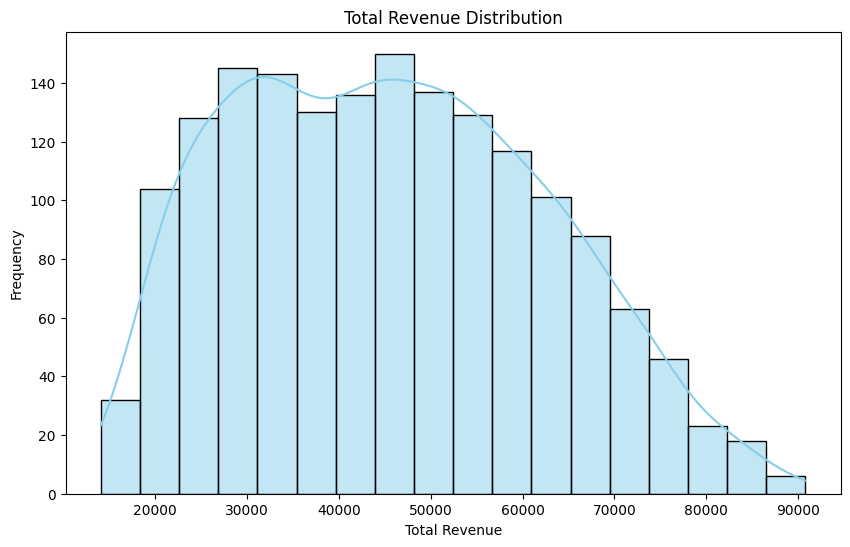

In [54]:
# Total Revenue Distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['TotalRevenue'],
    kde=True,
    color='skyblue'
)
plt.title("Total Revenue Distribution")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.show()

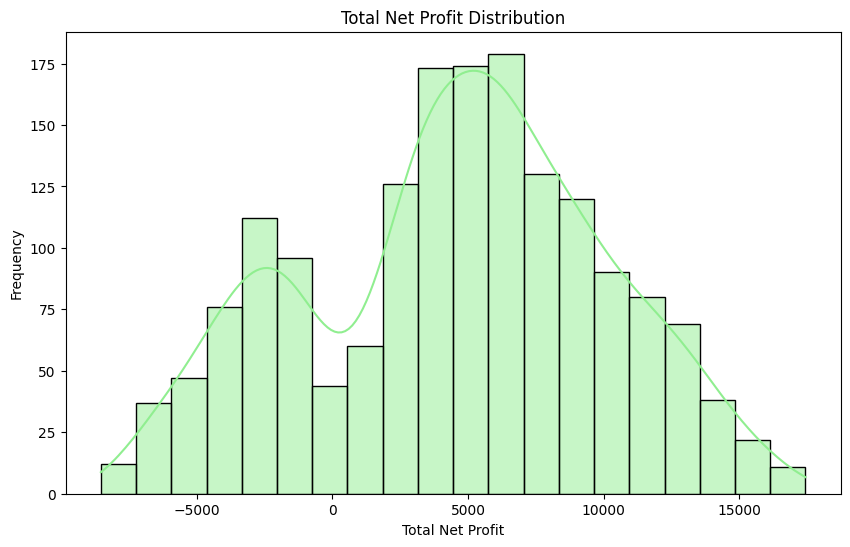

In [55]:
# Total Net Profit Distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['TotalNetProfit'],
    kde=True,
    color='lightgreen'
)
plt.title("Total Net Profit Distribution")
plt.xlabel("Total Net Profit")
plt.ylabel("Frequency")
plt.show()

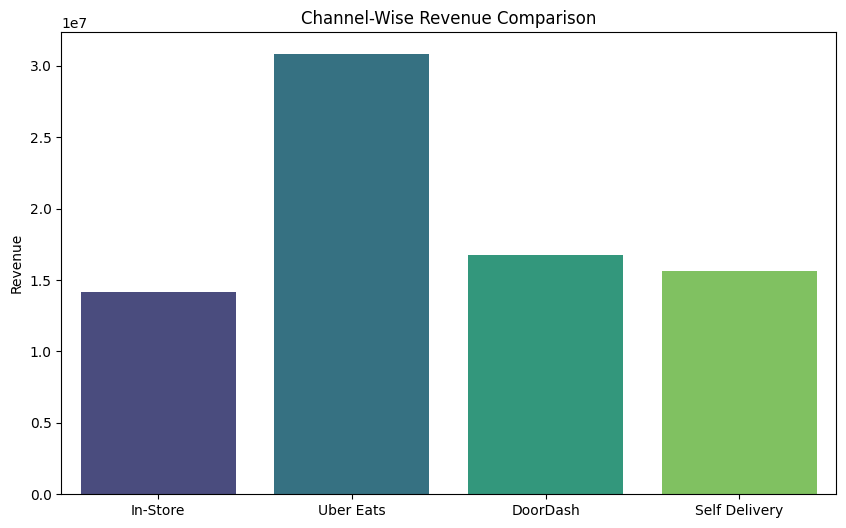

In [56]:
# Channel Wise Revenue Analysis
channel_revenue = [
    df['InStoreRevenue'].sum(),
    df['UberEatsRevenue'].sum(),
    df['DoorDashRevenue'].sum(),
    df['SelfDeliveryRevenue'].sum()
]
channels = [
    'In-Store',
    'Uber Eats',
    'DoorDash',
    'Self Delivery'
]
plt.figure(figsize=(10, 6))
sns.barplot(
    x=channels,
    y=channel_revenue,
    palette='viridis'
)
plt.title("Channel-Wise Revenue Comparison")
plt.ylabel("Revenue")
plt.show()

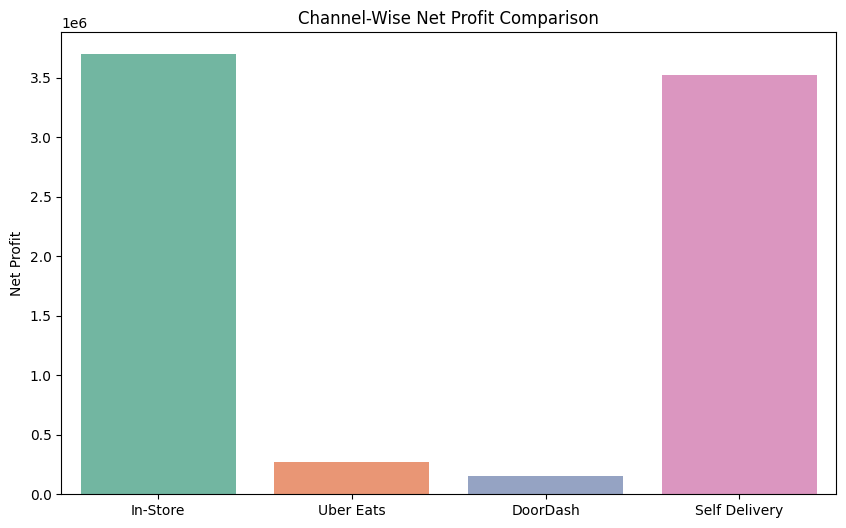

In [57]:
# Channel Wise Net Profit Analysis
channel_profit = [
    df['InStoreNetProfit'].sum(),
    df['UberEatsNetProfit'].sum(),
    df['DoorDashNetProfit'].sum(),
    df['SelfDeliveryNetProfit'].sum()
]
channels = [
    'In-Store',
    'Uber Eats',
    'DoorDash',
    'Self Delivery'
]
plt.figure(figsize=(10, 6))
sns.barplot(
    x=channels,
    y=channel_profit,
    palette='Set2'
)
plt.title("Channel-Wise Net Profit Comparison")
plt.ylabel("Net Profit")
plt.show()

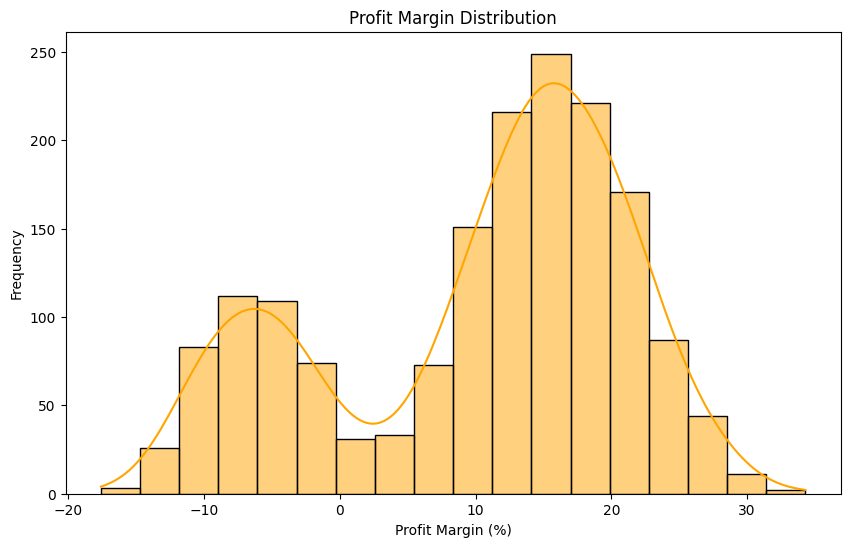

In [58]:
# Profit Margin Distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['ProfitMargin'],
    kde=True,
    color='orange'
)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.show()

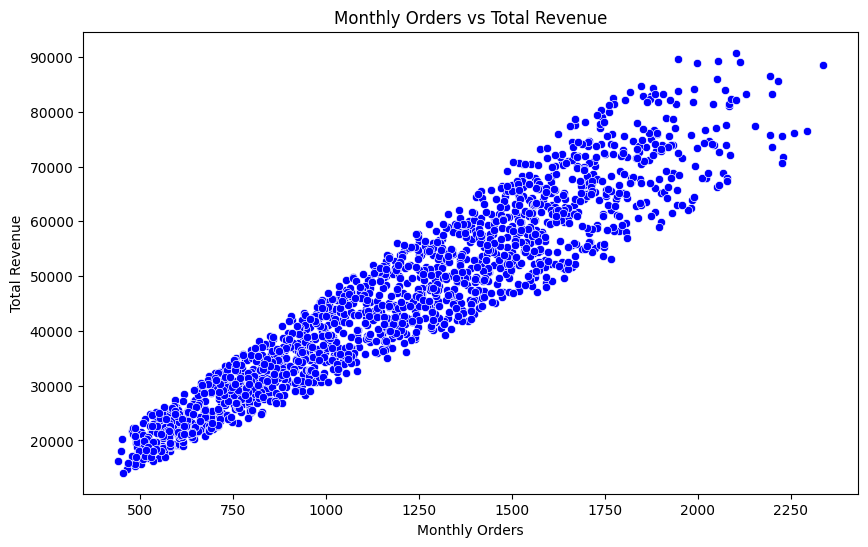

In [59]:
# Monthly Orders VS Total Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['MonthlyOrders'],
    y=df['TotalRevenue'],
    color='blue'
)
plt.title("Monthly Orders vs Total Revenue")
plt.xlabel("Monthly Orders")
plt.ylabel("Total Revenue")
plt.show()

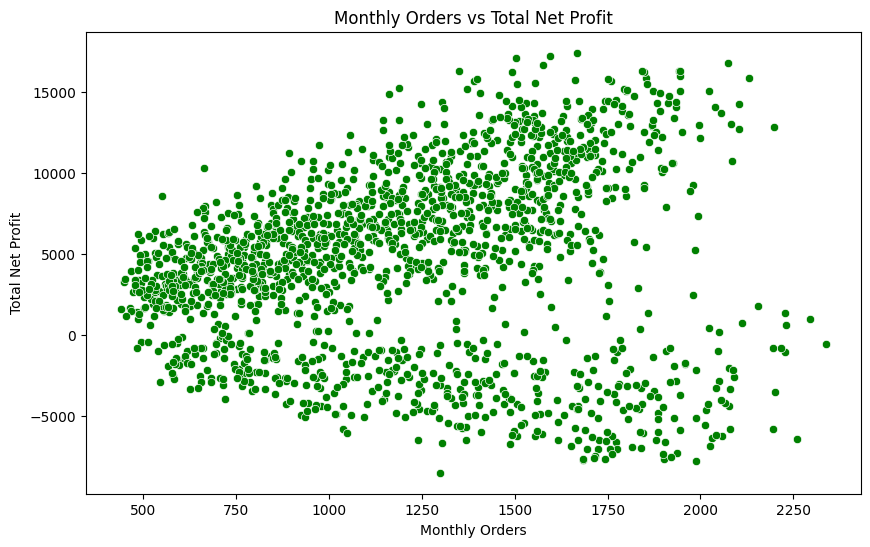

In [60]:
# Monthly Orders VS Total Net Profit 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['MonthlyOrders'],
    y=df['TotalNetProfit'],
    color='green'
)
plt.title("Monthly Orders vs Total Net Profit")
plt.xlabel("Monthly Orders")
plt.ylabel("Total Net Profit")
plt.show()

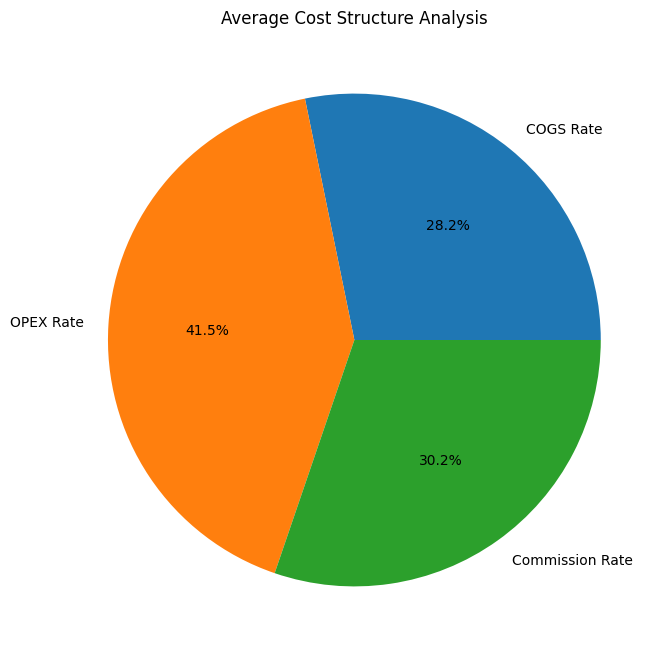

In [61]:
# Cost Structure Analysis
cost_components = [
    df['COGSRate'].mean(),
    df['OPEXRate'].mean(),
    df['CommissionRate'].mean()
]
labels = [
    'COGS Rate',
    'OPEX Rate',
    'Commission Rate'
]
plt.figure(figsize=(8, 8))
plt.pie(
    cost_components,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title("Average Cost Structure Analysis")
plt.show()

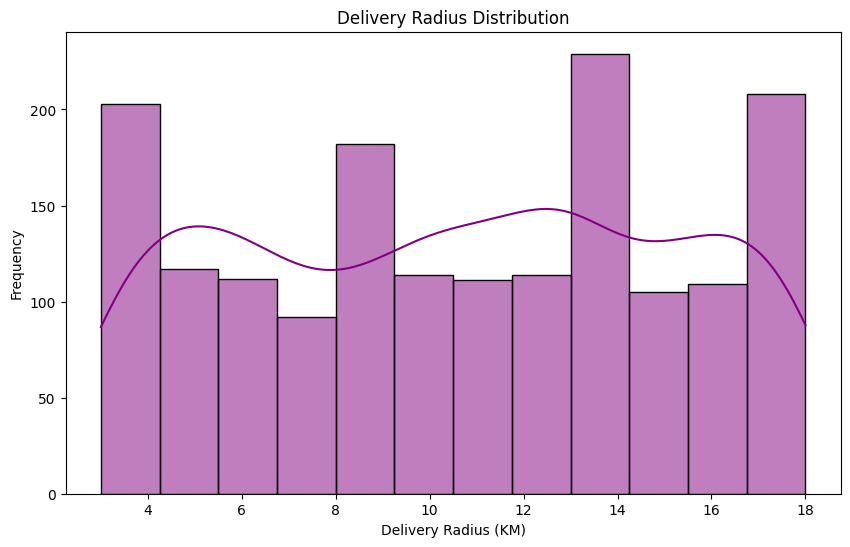

In [62]:
# Delivery Radius Distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['DeliveryRadiusKM'],
    kde=True,
    color='purple'
)
plt.title("Delivery Radius Distribution")
plt.xlabel("Delivery Radius (KM)")
plt.ylabel("Frequency")
plt.show()

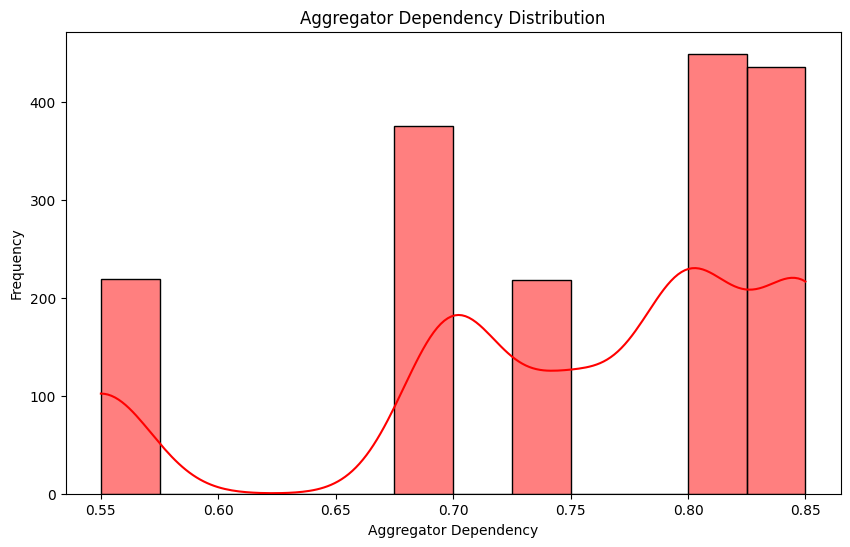

In [63]:
# Aggregator Dependency Analysis 
plt.figure(figsize=(10, 6))
sns.histplot(
    df['AggregatorDependency'],
    kde=True,
    color='red'
)
plt.title("Aggregator Dependency Distribution")
plt.xlabel("Aggregator Dependency")
plt.ylabel("Frequency")
plt.show()

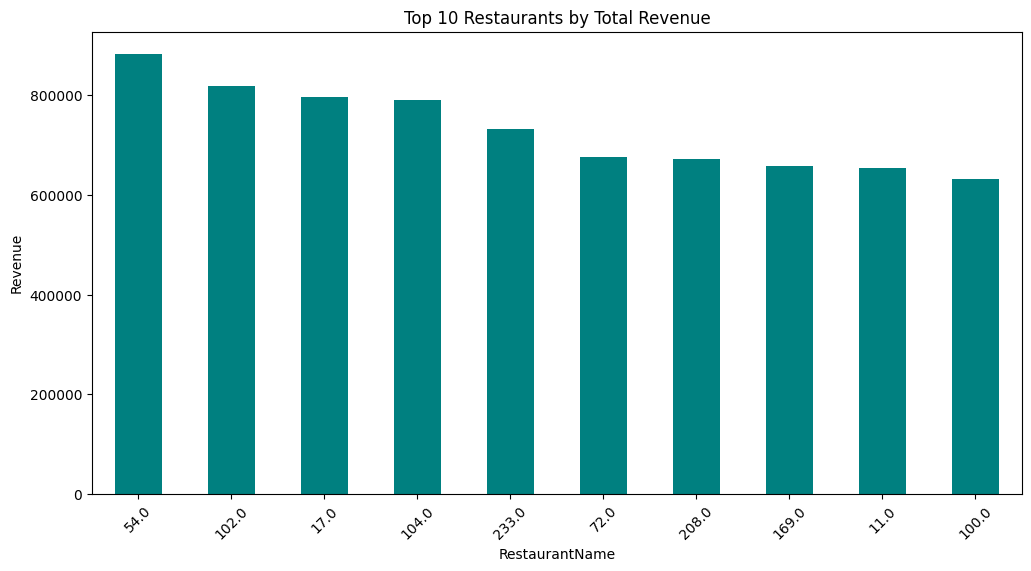

In [64]:
# Top 10 Resturants by Revenue
top_restaurants = df.groupby(
    'RestaurantName'
)['TotalRevenue'].sum().sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(12, 6))
top_restaurants.plot(
    kind='bar',
    color='teal'
)
plt.title("Top 10 Restaurants by Total Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

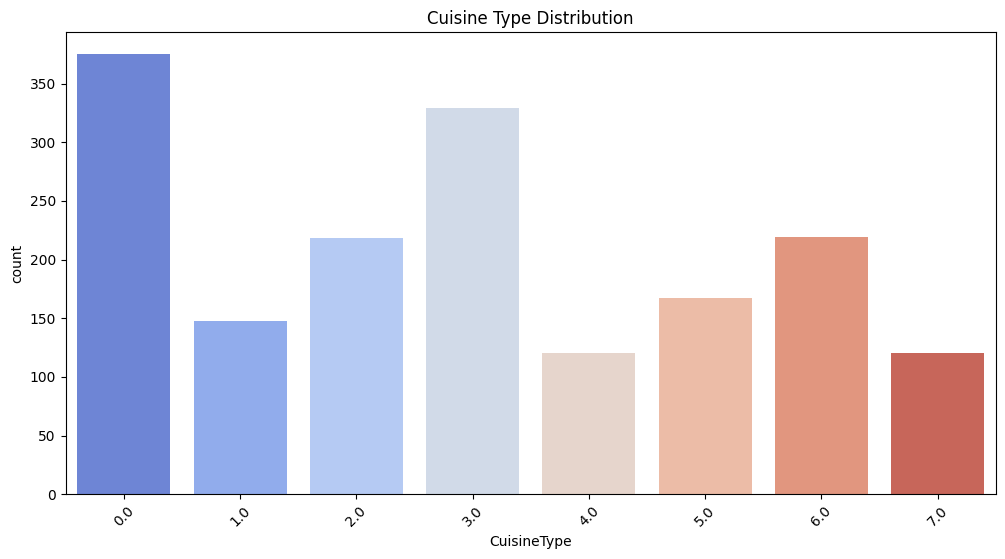

In [65]:
# Cuisine Type Distribution
plt.figure(figsize=(12, 6))
sns.countplot(
    x=df['CuisineType'],
    palette='coolwarm'
)
plt.title("Cuisine Type Distribution")
plt.xticks(rotation=45)
plt.show()

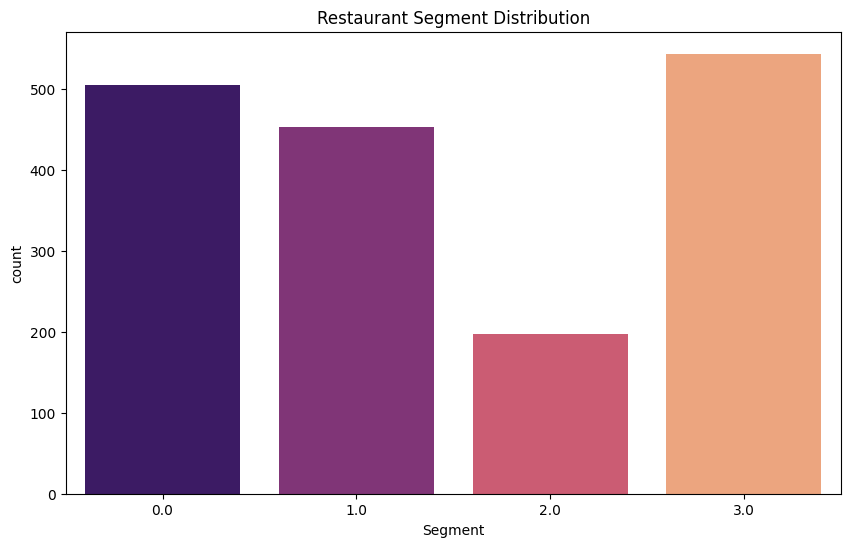

In [67]:
# Resturant Segement Distribution
plt.figure(figsize=(10, 6))
sns.countplot(
    x=df['Segment'],
    palette='magma'
)
plt.title("Restaurant Segment Distribution")
plt.show()

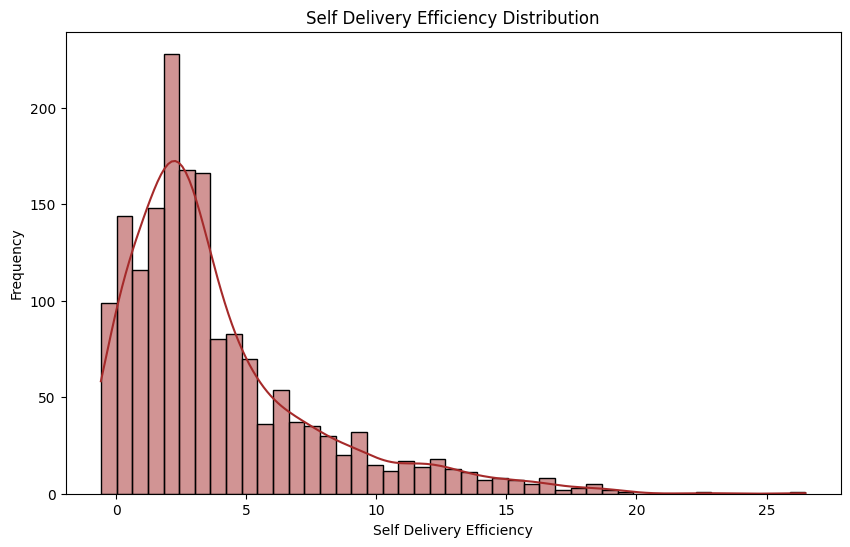

In [68]:
# Self Delivery Efficiency Distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['SelfDeliveryEfficiency'],
    kde=True,
    color='brown'
)
plt.title("Self Delivery Efficiency Distribution")
plt.xlabel("Self Delivery Efficiency")
plt.ylabel("Frequency")
plt.show()

In [69]:
# Selecting Features for Clustering

cluster_features = [
    'TotalRevenue',
    'TotalNetProfit',
    'ProfitMargin',
    'MonthlyOrders',
    'AggregatorDependency',
    'SelfDeliveryEfficiency'
]

X_cluster = df[cluster_features]

X_cluster.head()

,TotalRevenue,TotalNetProfit,ProfitMargin,MonthlyOrders,AggregatorDependency,SelfDeliveryEfficiency
0,29371.96,7964.560,27.116202,668.0,0.7,4.751097
1,56144.60,8775.700,15.630533,1388.0,0.7,1.949515
2,68731.51,12028.665,17.500947,1717.0,0.7,3.586584
3,39291.24,5266.830,13.404591,1083.0,0.7,12.243993
4,42238.20,6119.350,14.487715,1230.0,0.7,3.455236


In [70]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled[:5]


array([[-0.97150932,  0.62784429,  1.53012686, -1.23759912, -0.54999718,
         0.21765263],
       [ 0.63074539,  0.77515643,  0.48528484,  0.4677121 , -0.54999718,
        -0.52557199],
       [ 1.38403068,  1.36593145,  0.6554349 ,  1.2469446 , -0.54999718,
        -0.09127813],
       [-0.37787294,  0.13790619,  0.28279274, -0.25467668, -0.54999718,
         2.20542455],
       [-0.20150704,  0.2927334 ,  0.38132364,  0.09349103, -0.54999718,
        -0.126123  ]])

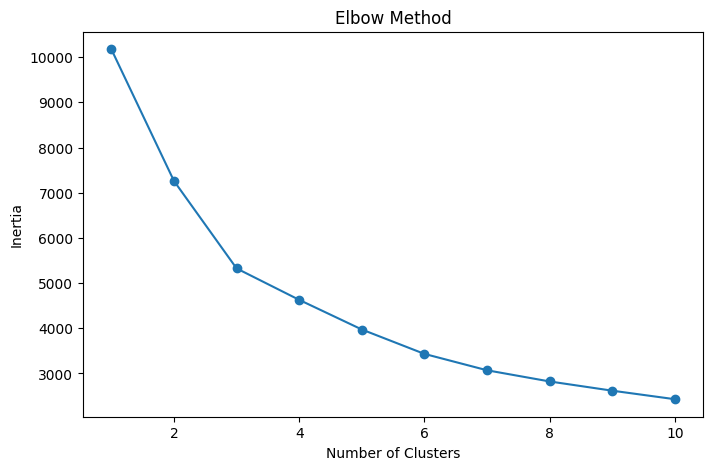

In [71]:
# Finding Optimal Number of Clusters

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [72]:
# Applying K-Means Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Cluster']].head()

,Cluster
0,0
1,1
2,1
3,3
4,1


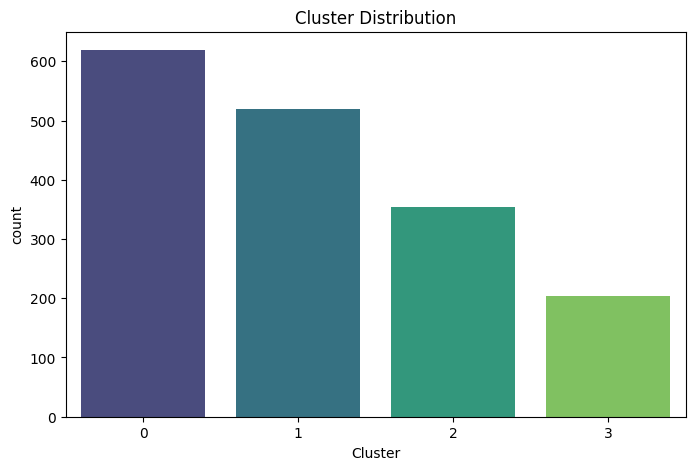

In [73]:
# Cluster Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df,
    palette='viridis'
)

plt.title("Cluster Distribution")

plt.show()

In [74]:
# Applying PCA

pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

# Creating PCA DataFrame

pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['Cluster']

pca_df.head()

,PC1,PC2,Cluster
0,1.264565,-1.726455,0
1,0.781954,0.832107,1
2,1.612189,1.757676,1
3,1.264444,-0.768286,3
4,0.452995,-0.028737,1


In [75]:
# Explained Variance Ratio

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio: [0.39196243 0.33939137]
Total Explained Variance: 0.7313538064463716


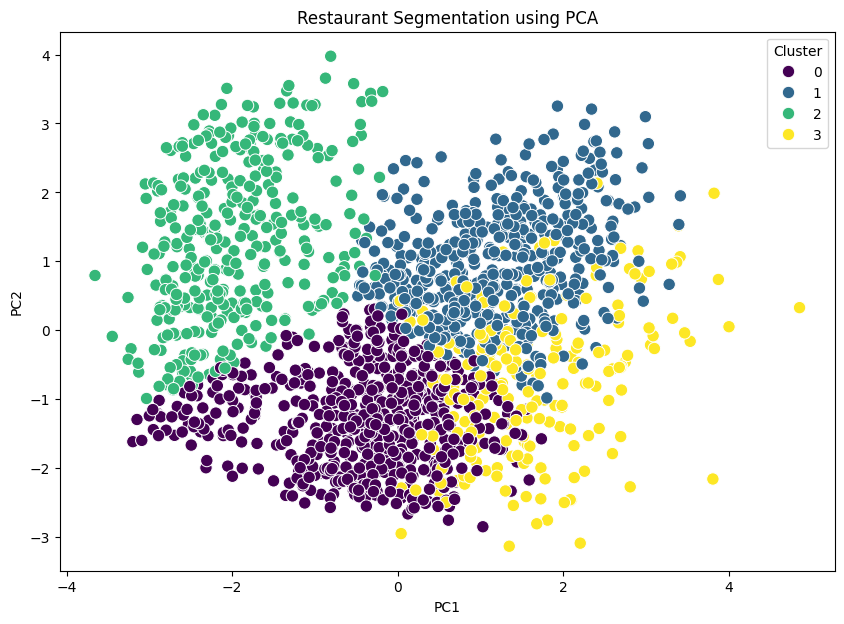

In [76]:
# PCA Cluster Visualization

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title(
    "Restaurant Segmentation using PCA"
)

plt.show()

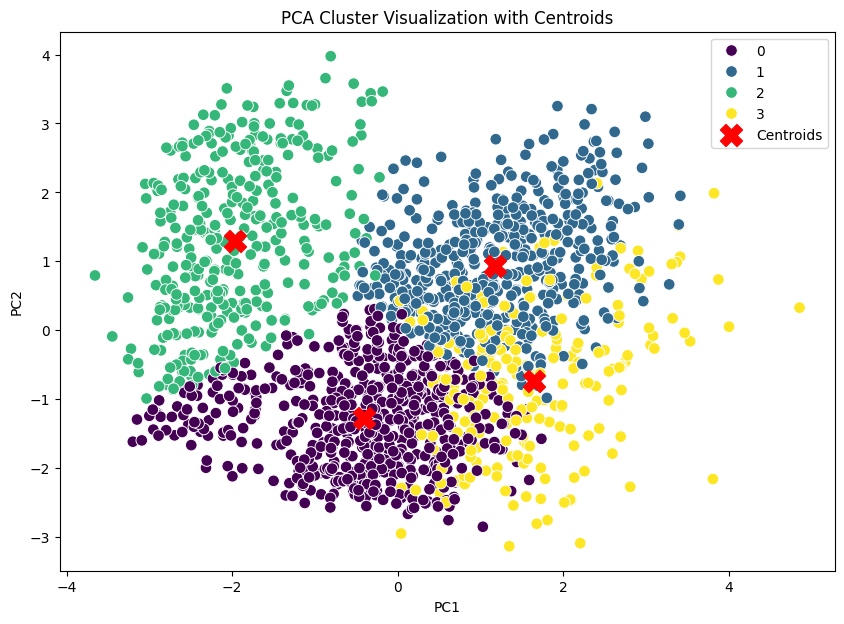

In [77]:
# Transforming Cluster Centers

centers = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red',
    s=250,
    marker='X',
    label='Centroids'
)

plt.legend()

plt.title(
    "PCA Cluster Visualization with Centroids"
)

plt.show()

In [78]:
# Cluster Summary Statistics

cluster_summary = df.groupby('Cluster')[
    [
        'TotalRevenue',
        'TotalNetProfit',
        'ProfitMargin',
        'MonthlyOrders',
        'AggregatorDependency',
        'SelfDeliveryEfficiency'
    ]
].mean()

cluster_summary

,TotalRevenue,TotalNetProfit,ProfitMargin,MonthlyOrders,AggregatorDependency,SelfDeliveryEfficiency
Cluster,,,,,,
0,30029.749822,3485.334120,11.521935,796.248788,0.774798,3.125340
1,58017.626802,9716.024935,16.939435,1499.373796,0.720135,3.886019
2,55780.150434,-3217.587832,-6.052776,1479.129944,0.752542,0.844994
3,43631.232157,7763.119259,18.043768,1100.338235,0.762990,11.842331


In [79]:
# Cluster Size

df['Cluster'].value_counts()

Cluster
0    619
1    519
2    354
3    204
Name: count, dtype: int64

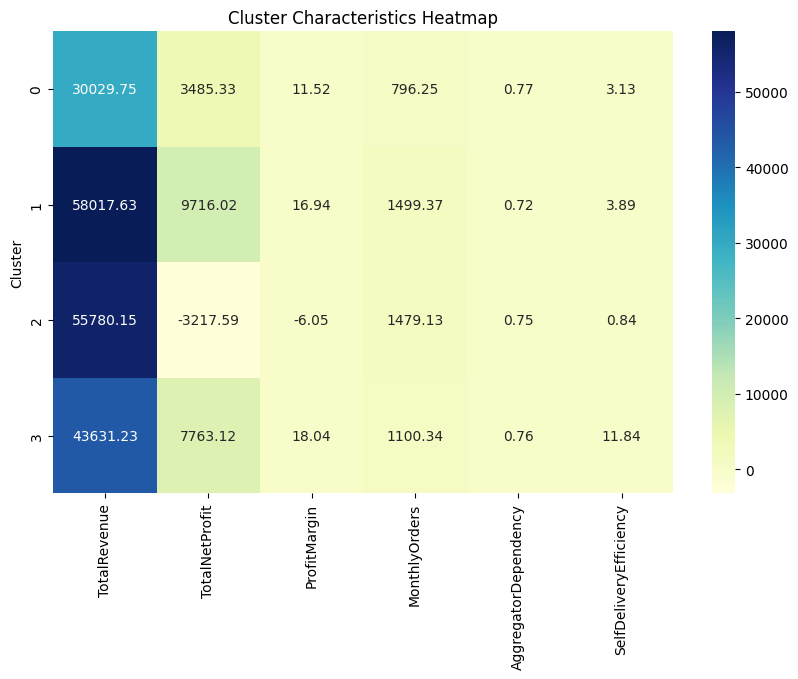

In [80]:
# Cluster Summary Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title(
    "Cluster Characteristics Heatmap"
)

plt.show()

In [81]:
# Creating Target Variable

df['ProfitClass'] = np.where(
    df['TotalNetProfit'] >
    df['TotalNetProfit'].median(),
    1,
    0
)

df['ProfitClass'].value_counts()

ProfitClass
1    848
0    848
Name: count, dtype: int64

In [82]:
# Selecting Features
features = [
    'MonthlyOrders',
    'AOV',
    'InStoreRevenue',
    'UberEatsRevenue',
    'DoorDashRevenue',
    'SelfDeliveryRevenue',
    'COGSRate',
    'OPEXRate',
    'CommissionRate',
    'AggregatorDependency',
    'SelfDeliveryEfficiency',
    'ProfitMargin'
]

X = df[features]

y = df['ProfitClass']

In [83]:
# Splitting Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1356, 12)
(340, 12)


In [84]:
# Standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [85]:
# Logistic Regression
lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(X_test_scaled)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       170
           1       0.97      0.94      0.95       170

    accuracy                           0.95       340
   macro avg       0.95      0.95      0.95       340
weighted avg       0.95      0.95      0.95       340



In [86]:
# Random Forest
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       170
           1       0.99      0.98      0.99       170

    accuracy                           0.99       340
   macro avg       0.99      0.99      0.99       340
weighted avg       0.99      0.99      0.99       340



In [87]:
# XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(
    X_train,
    y_train
)
xgb_pred = xgb.predict(X_test)
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       170
           1       0.99      0.99      0.99       170

    accuracy                           0.99       340
   macro avg       0.99      0.99      0.99       340
weighted avg       0.99      0.99      0.99       340



In [88]:
# LightGBM
lgbm = LGBMClassifier(
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm.predict(X_test)

print(
    classification_report(
        y_test,
        lgbm_pred
    )
)

[LightGBM] [Info] Number of positive: 678, number of negative: 678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2564
[LightGBM] [Info] Number of data points in the train set: 1356, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       170
           1       0.98      0.99      0.99       170

    accuracy                           0.99       340
   macro avg       0.99      0.99      0.99       340
weighted avg       0.99      0.99      0.99       340



In [89]:
# Accuracy Comparison

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],

    'Accuracy': [

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            xgb_pred
        ),

        accuracy_score(
            y_test,
            lgbm_pred
        )

    ]

})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,LightGBM,0.988235
2,XGBoost,0.988235
1,Random Forest,0.985294
0,Logistic Regression,0.952941


In [90]:
# Random Forest Feature Importance

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
11,ProfitMargin,0.310422
7,OPEXRate,0.155124
5,SelfDeliveryRevenue,0.113127
6,COGSRate,0.096453
10,SelfDeliveryEfficiency,0.087910
0,MonthlyOrders,0.072557
3,UberEatsRevenue,0.048128
4,DoorDashRevenue,0.041805
2,InStoreRevenue,0.038157
1,AOV,0.016871


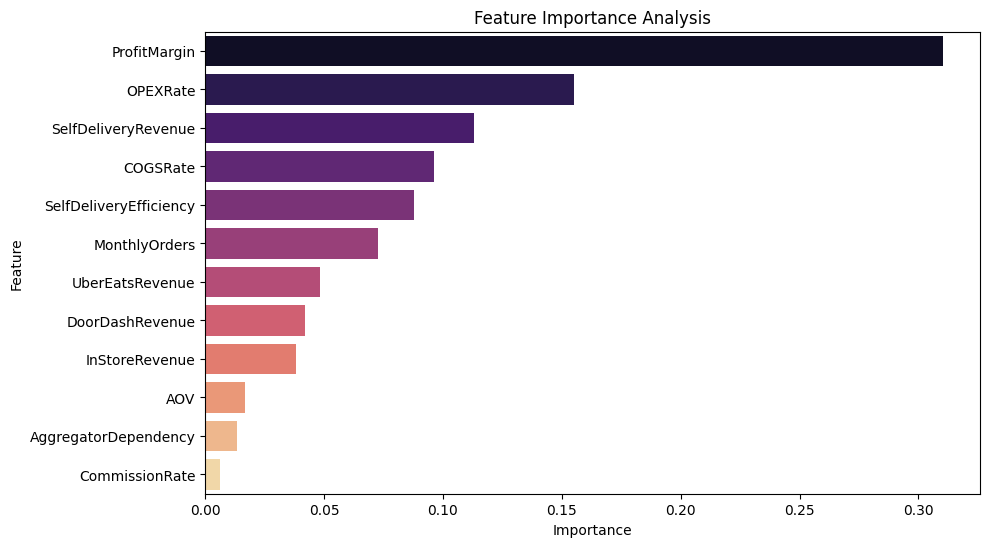

In [91]:
# Feature Importance Plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette='magma'
)

plt.title(
    'Feature Importance Analysis'
)

plt.show()

In [92]:
# Save Final Dataset

df.to_csv(
    "restaurant_profitability_final.csv",
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.


In [93]:
import joblib

joblib.dump(
    lgbm,
    "lightgbm_profitability_model.pkl"
)

print("LightGBM model exported successfully.")

LightGBM model exported successfully.


In [94]:
joblib.dump(
    rf,
    "random_forest_model.pkl"
)

print("Random Forest model exported successfully.")

Random Forest model exported successfully.


In [95]:
joblib.dump(
    xgb,
    "xgboost_profitability_model.pkl"
)

print("XGBoost model exported successfully.")

XGBoost model exported successfully.


In [96]:
joblib.dump(
    lr,
    "logistic_regression_model.pkl"
)

print("Logistic Regression model exported successfully.")

Logistic Regression model exported successfully.


In [97]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler exported successfully.")

Scaler exported successfully.


In [98]:
joblib.dump(
    pca,
    "pca_model.pkl"
)

print("PCA model exported successfully.")

PCA model exported successfully.


In [99]:
joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

print("KMeans model exported successfully.")

KMeans model exported successfully.


In [101]:
import os

print(os.listdir())

print(os.listdir("Models"))

['.venv', 'app.py', 'Models', 'Multi_Channel_Restaurant.ipynb', 'requirements.txt', 'restaurant_profitability_final.csv', 'SkyCity Auckland Restaurants & Bars.csv']
['kmeans_model.pkl', 'lightgbm_profitability_model.pkl', 'logistic_regression_model.pkl', 'pca_model.pkl', 'random_forest_model.pkl', 'scaler.pkl', 'xgboost_profitability_model.pkl']
